In [9]:
import re
import matplotlib.pyplot as plt
import os

def plot_time_improvement(filename):
    """
    Parse a HYBRID func1/func2 log file and plot forward-weight improvement vs time.

    Supports two log line formats:

    1) CSV-style (standard):
       [ts] phase_idx, phase_type, duration_sec, fw_before, fw_after, ...

    2) Pretty pipe-style (old func1_everyN_global lines):
       [ts] 100 | func1_every50_global | dur=123.45s | FW: A -> B (Δ=...) | ...

    Also:
    - Automatically saves the plot.
    - Filename = last 10 chars of input *basename* + '_improvement.png'
    - If the file already exists, it is deleted before saving.
    """

    cumulative_times = []    # cumulative time in seconds
    improvements = []        # fw_after - fw_initial
    phases = []              # phase indices (optional)

    fw_initial = None
    cum_time = 0.0

    # Basename (no directories)
    base = os.path.basename(filename)

    # Title suffix (last 15 chars of basename)
    suffix15 = base[-15:] if len(base) > 15 else base

    # Output image name based on last 10 chars of basename
    # Output image name = full basename + suffix
    image_name = f"{base}_improvement.png"


    ts_pattern = re.compile(r"^\[(.*?)\]\s*(.*)$")
    dur_re = re.compile(r"dur\s*=\s*([0-9.]+)s")
    fw_re = re.compile(r"FW:\s*([0-9.+-]+)\s*->\s*([0-9.+-]+)")

    def parse_line(line):
        """
        Try to parse a line in either CSV-style or pretty pipe-style.
        Returns (phase_idx, duration_sec, fw_before, fw_after) or None.
        """
        m = ts_pattern.match(line)
        if not m:
            return None
        rest = m.group(2).strip()
        if not rest:
            return None

        # --- First try CSV-style: split on commas (up to 10 parts) ---
        parts = [p.strip() for p in rest.split(",", 9)]
        if len(parts) >= 5:
            try:
                phase_idx = int(parts[0])
                duration_sec = float(parts[2])
                fw_before = float(parts[3])
                fw_after = float(parts[4])
                return phase_idx, duration_sec, fw_before, fw_after
            except ValueError:
                pass  # fall through

        # --- Try pretty pipe-style ---
        if "|" in rest:
            segments = [s.strip() for s in rest.split("|")]
            if len(segments) >= 4:
                try:
                    phase_idx = int(segments[0])
                except ValueError:
                    return None

                dur_match = dur_re.search(segments[2])  # usually segments[2]
                fw_match = fw_re.search(rest)           # search whole rest for FW pattern
                if dur_match and fw_match:
                    try:
                        duration_sec = float(dur_match.group(1))
                        fw_before = float(fw_match.group(1))
                        fw_after = float(fw_match.group(2))
                        return phase_idx, duration_sec, fw_before, fw_after
                    except ValueError:
                        return None

        return None

    # --- Read file and parse ---
    # Also keep a small header buffer for CPU fallback extraction
    header_lines = []
    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            raw = line.rstrip("\n")
            if i < 50:
                header_lines.append(raw)

            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if "]" not in line:
                continue

            parsed = parse_line(line)
            if parsed is None:
                continue

            phase_idx, duration_sec, fw_before, fw_after = parsed

            if fw_initial is None:
                fw_initial = fw_before  # baseline FW

            cum_time += duration_sec
            cumulative_times.append(cum_time)
            improvements.append(fw_after - fw_initial)
            phases.append(phase_idx)

    if not cumulative_times:
        print("No valid data found in file:", filename)
        return

    # --- Extract CPU count robustly ---
    # 1) Prefer filename, matching things like:
    #    "...-12cpu-second72.txt", "..._48cpu.txt", "...48cpu...", etc.
    cpu_matches = re.findall(r"(\d+)\s*cpu\b", base, flags=re.IGNORECASE)
    n_cpus = int(cpu_matches[-1]) if cpu_matches else None

    # 2) Fallback: scan header lines (e.g., ranking_csv = ...-48cpu-...)
    if n_cpus is None:
        header_text = "\n".join(header_lines)
        cpu_matches2 = re.findall(r"(\d+)\s*cpu\b", header_text, flags=re.IGNORECASE)
        if cpu_matches2:
            n_cpus = int(cpu_matches2[-1])

    # 3) If still None, don't crash; just use "unknown"
    cpu_label = f"{n_cpus} CPUs" if n_cpus is not None else "unknown CPUs"

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.plot(cumulative_times, improvements, marker="o", linewidth=1.5)
    plt.xlabel("Cumulative time (seconds)")
    plt.ylabel("Forward-weight improvement (FW_after - FW_initial)")
    plt.title(f"Forward-weight improvement over time for {cpu_label} ({suffix15})")

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # --- Save ---
    if os.path.exists(image_name):
        os.remove(image_name)

    plt.savefig(image_name, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {image_name}")
    plt.show()


Saved figure to: connectome_35435948_changes_log-12cpu.txt_improvement.png


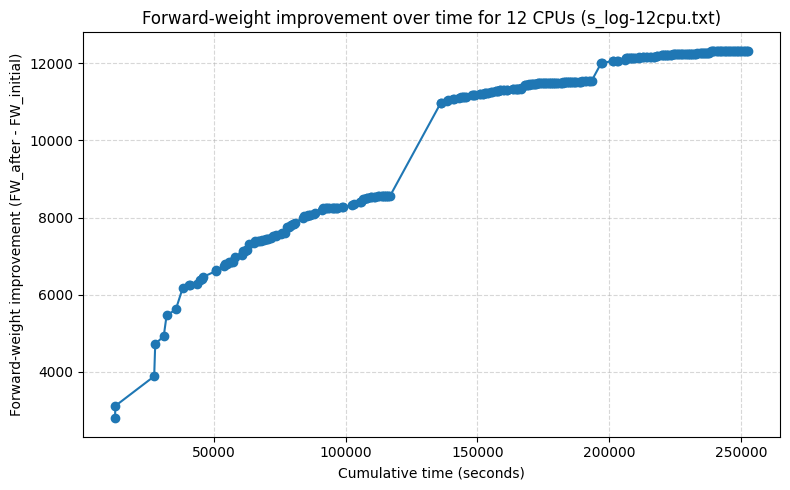

In [15]:
plot_time_improvement("connectome_35435948_changes_log-12cpu.txt")



Saved figure to: connectome_35435948_changes_log-24cpu.txt_improvement.png


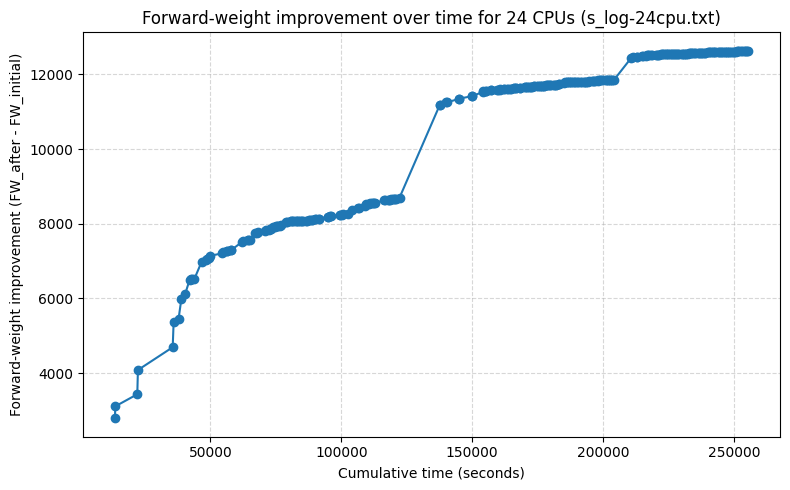

In [16]:
plot_time_improvement("connectome_35435948_changes_log-24cpu.txt")

Saved figure to: connectome_35435948_changes_log-48cpu.txt_improvement.png


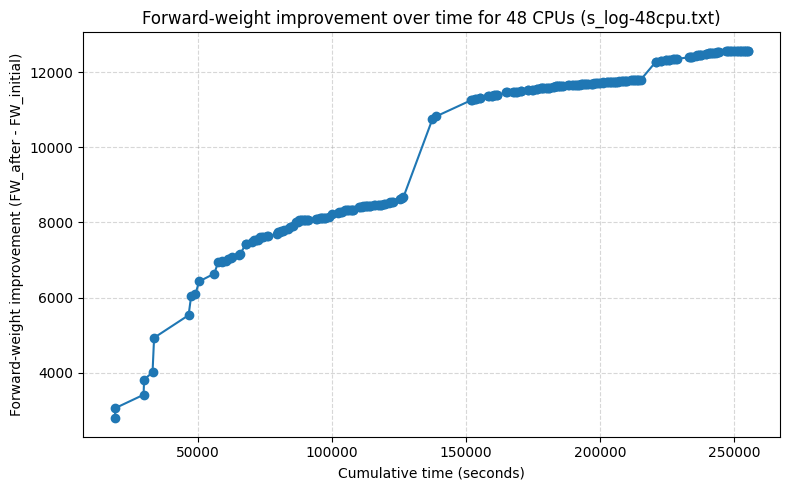

In [17]:
plot_time_improvement("connectome_35435948_changes_log-48cpu.txt")

In [6]:
import re
import matplotlib.pyplot as plt
import os

def plot_time_fw_for_function(log_filename: str, mode: str = "func1"):
    
    """
    Plot cumulative time vs cumulative FW improvement for a given family of phases.

    Parameters
    ----------
    log_filename : str
        Path to the HYBRID log file.
    mode : str
        Which family to plot: "func1", "func2", or "other".

        - "func1": phases whose phase_type starts with "func1"
                   EXCLUDING special globals like "func1_every50_global".
        - "func2": phases whose phase_type starts with "func2".
        - "other": everything else (including "func1_every*_global" and any
                   non-func1/non-func2 phase types).

    Behavior
    --------
    Parses lines in two formats:

    1) CSV-style (standard):
       [ts] phase_idx, phase_type, duration_sec, fw_before, fw_after, num_B2F, wt_B2F, num_F2B, wt_F2B, extra

    2) Pretty pipe-style:
       [ts]  100  |  func1_every50_global  |  dur=123.45s  |  FW: A -> B (Δ=+X)  |  ...

    For phases in the selected mode, it plots:
        x = cumulative time (sum of duration_sec over selected phases)
        y = cumulative sum of (fw_after - fw_before) for those phases

    The figure is automatically saved as:
        <last 10 chars of filename>_<mode>.png
    (overwriting if it already exists).
    """

    mode = mode.strip().lower()
    if mode not in {"func1", "func2", "other"}:
        raise ValueError("mode must be one of: 'func1', 'func2', 'other'")

    ts_pattern = re.compile(r"^\[(.*?)\]\s*(.*)$")
    dur_re = re.compile(r"dur\s*=\s*([0-9.]+)s")
    fw_re = re.compile(r"FW:\s*([0-9.+-]+)\s*->\s*([0-9.+-]+)")

    def classify_family(phase_type: str) -> str:
        """
        Classify phase_type into 'func1', 'func2', or 'other'.

        - 'func1_every*_global' and any non-func1/non-func2 phases go to 'other'.
        """
        if phase_type.startswith("func1_every"):
            return "other"
        if phase_type.startswith("func1"):
            return "func1"
        if phase_type.startswith("func2"):
            return "func2"
        return "other"

    def parse_line(rest: str):
        """
        Try to parse 'rest' (after the timestamp) as:
        - CSV-style: 'phase_idx, phase_type, duration, fw_before, fw_after, ...'
        - Pipe-style: 'phase_idx  |  phase_type  |  dur=... | FW: A -> B (...) | ...'

        Returns:
            (phase_type, duration_sec, fw_before, fw_after) or None on failure.
        """
        # --- Try CSV-style first ---
        parts = [p.strip() for p in rest.split(",", 9)]
        if len(parts) >= 5:
            try:
                phase_type = parts[1]
                duration_sec = float(parts[2])
                fw_before = float(parts[3])
                fw_after = float(parts[4])
                return phase_type, duration_sec, fw_before, fw_after
            except ValueError:
                # fall through to pretty-style parsing
                pass

        # --- Try pretty pipe-style ---
        if "|" in rest:
            segments = [s.strip() for s in rest.split("|")]
            # expected: [phase_idx, phase_type, "dur=...", "FW: A -> B (Δ=...)", ...]
            if len(segments) >= 4:
                phase_str = segments[0]
                phase_type = segments[1]

                dur_match = dur_re.search(segments[2])
                fw_match = fw_re.search(rest)

                if dur_match and fw_match:
                    try:
                        _ = int(phase_str)  # ensure phase index is a valid int
                        duration_sec = float(dur_match.group(1))
                        fw_before = float(fw_match.group(1))
                        fw_after = float(fw_match.group(2))
                        return phase_type, duration_sec, fw_before, fw_after
                    except ValueError:
                        return None

        return None

    cumulative_time = 0.0
    cumulative_improvement = 0.0
    times = []
    improvements = []

    # Extract just the file name (not full path)
    base_name = os.path.basename(log_filename)
    suffix_15 = base_name if len(base_name) > 15 else base_name
    suffix_10 = base_name if len(base_name) > 10 else base_name

    with open(log_filename, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            m = ts_pattern.match(line)
            if not m:
                continue

            rest = m.group(2).strip()
            if not rest:
                continue

            parsed = parse_line(rest)
            if parsed is None:
                continue

            phase_type, duration_sec, fw_before, fw_after = parsed
            family = classify_family(phase_type)

            # Only keep the desired family
            if family != mode:
                continue

            cumulative_time += duration_sec
            delta_fw = fw_after - fw_before
            cumulative_improvement += delta_fw

            times.append(cumulative_time)
            improvements.append(cumulative_improvement)

    if not times:
        print(f"No phases found for {mode} in file {log_filename}")
        return
    if mode=="func2":
        mode="SCC-Shuffle"
    if mode=="func1":
        mode="Interval-Sweep"
    if mode=="other":
        mode="global"
    plt.figure()
    plt.plot(times, improvements, marker="o")
    plt.xlabel(f"Cumulative time in {mode} phases (seconds)")
    plt.ylabel(f"Cumulative FW improvement by {mode}")
    plt.title(f"Cumulative time vs FW improvement for {mode} with 12 CPUs")

    plt.grid(True)
    plt.tight_layout()

    image_name = f"{suffix_10}_{mode}.png"
    if os.path.exists(image_name):
        os.remove(image_name)

    plt.savefig(image_name, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {image_name}")

    plt.show()


Saved figure to: connectome_35435948_changes_log-12cpu-second72.txt_Interval-Sweep.png


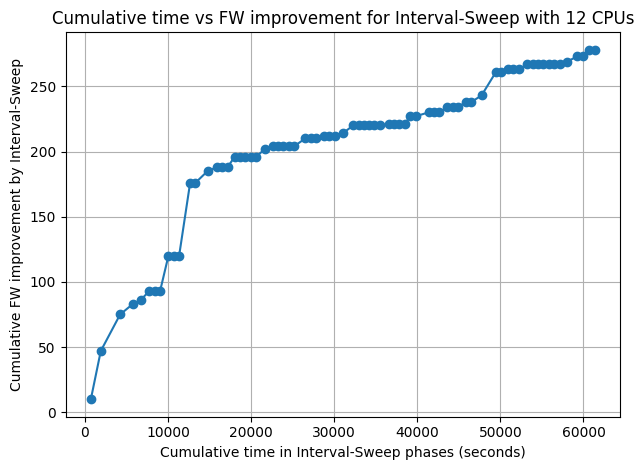

Saved figure to: connectome_35435948_changes_log-12cpu-second72.txt_SCC-Shuffle.png


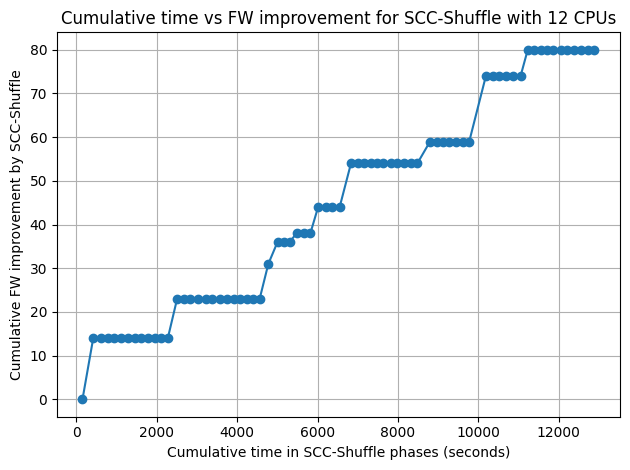

Saved figure to: connectome_35435948_changes_log-12cpu-second72.txt_global.png


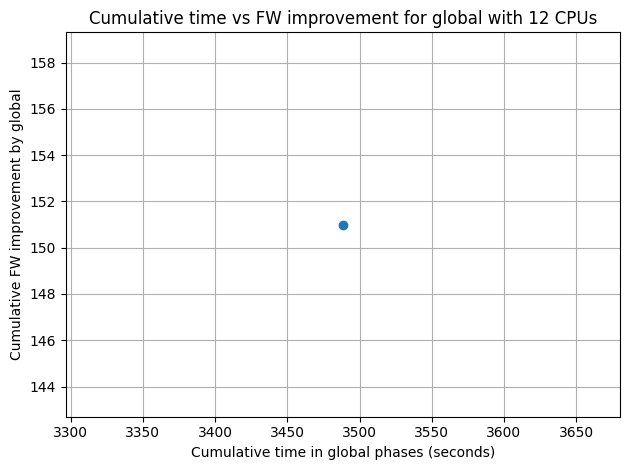

In [31]:
plot_time_fw_for_function("connectome_35435948_changes_log-12cpu-second72.txt", mode="func1")
plot_time_fw_for_function("connectome_35435948_changes_log-12cpu-second72.txt", mode="func2")
plot_time_fw_for_function("connectome_35435948_changes_log-12cpu-second72.txt", mode="other")


Saved figure to: connectome_hybrid_phases_direction_changes_log-24cpu.txt_func1.png


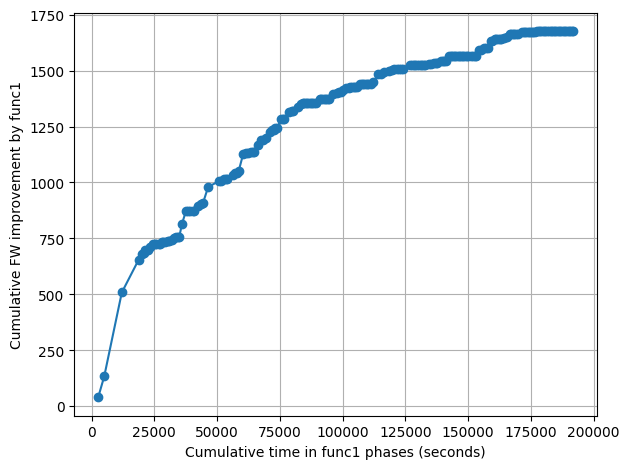

Saved figure to: connectome_hybrid_phases_direction_changes_log-24cpu.txt_func2.png


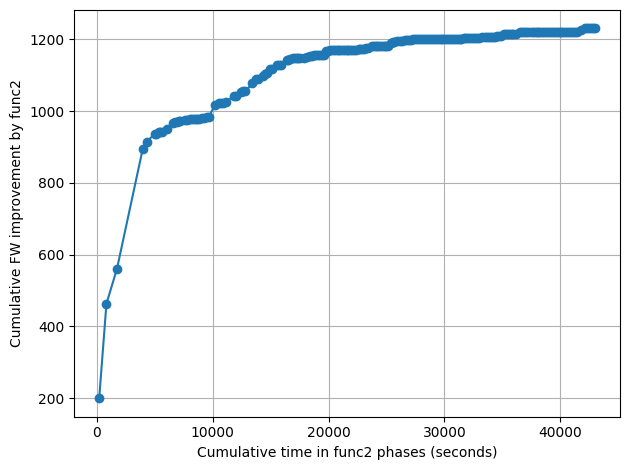

Saved figure to: connectome_hybrid_phases_direction_changes_log-24cpu.txt_other.png


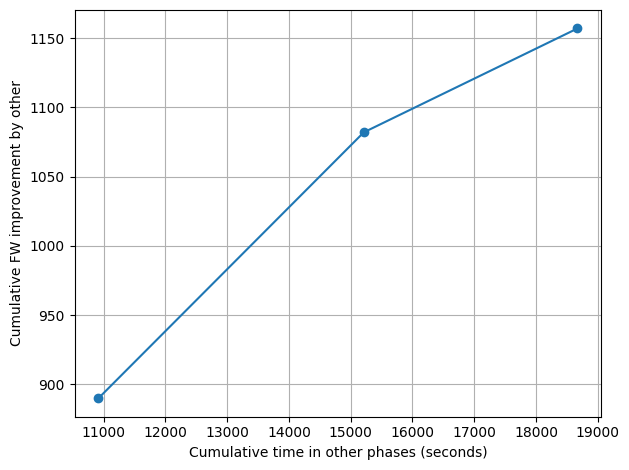

In [21]:
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-24cpu.txt", mode="func1")
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-24cpu.txt", mode="func2")
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-24cpu.txt", mode="other")

Saved figure to: -12cpu.txt_func1.png


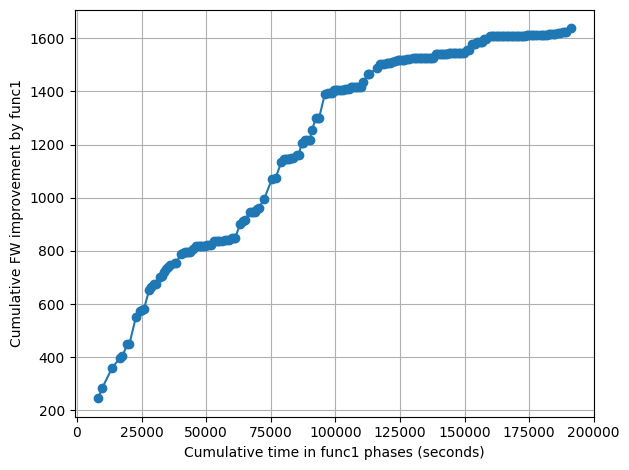

Saved figure to: -12cpu.txt_func2.png


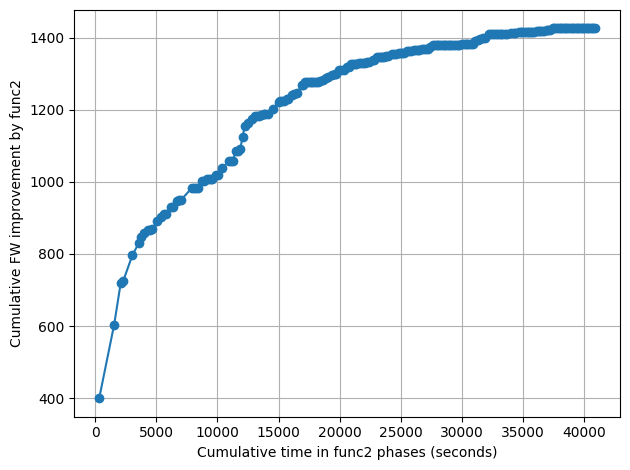

Saved figure to: -12cpu.txt_other.png


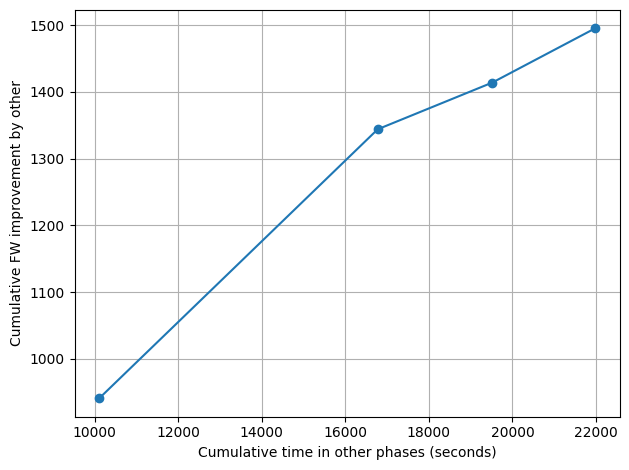

In [8]:
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-12cpu.txt", mode="func1")
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-12cpu.txt", mode="func2")
plot_time_fw_for_function("connectome_hybrid_phases_direction_changes_log-12cpu.txt", mode="other")


In [41]:
import re
import os
from typing import Optional, Tuple, Dict, List

# Shared regexes (same idea as in inspect_fw_mismatch)
_TS_PATTERN = re.compile(r"^\[(.*?)\]\s*(.*)$")
_DUR_RE = re.compile(r"dur\s*=\s*([0-9.]+)s")
_FW_RE = re.compile(r"FW:\s*([0-9.+-]+)\s*->\s*([0-9.+-]+)")


def _parse_csv_style(rest: str) -> Optional[Tuple[int, str, float, float, float]]:
    """
    CSV-style:
        phase_idx, phase_type, duration_sec, fw_before, fw_after, ...
    """
    parts = [p.strip() for p in rest.split(",", 9)]
    if len(parts) < 5:
        return None
    try:
        phase_idx = int(parts[0])
        phase_type = parts[1]
        duration_sec = float(parts[2])
        fw_before = float(parts[3])
        fw_after = float(parts[4])
        return phase_idx, phase_type, duration_sec, fw_before, fw_after
    except ValueError:
        return None


def _parse_pipe_style(rest: str) -> Optional[Tuple[int, str, float, float, float]]:
    """
    Pretty pipe-style:
        phase_idx  |  phase_type  |  dur=123.45s  |  FW: A -> B (Δ=+X)  |  ...
    """
    if "|" not in rest:
        return None

    segments = [s.strip() for s in rest.split("|")]
    # expected approx: [phase_idx, phase_type, "dur=..", "FW: A -> B (Δ=..)", ...]
    if len(segments) < 4:
        return None

    phase_str = segments[0]
    phase_type = segments[1]

    dur_match = _DUR_RE.search(segments[2])
    fw_match = _FW_RE.search(rest)

    if not dur_match or not fw_match:
        return None

    try:
        phase_idx = int(phase_str)
        duration_sec = float(dur_match.group(1))
        fw_before = float(fw_match.group(1))
        fw_after = float(fw_match.group(2))
        return phase_idx, phase_type, duration_sec, fw_before, fw_after
    except ValueError:
        return None


def parse_global_style(line: str) -> Optional[Tuple[int, str, float, float, float]]:
    """
    Emulate the UPDATED global plot parser (plot_time_improvement):

    - skips empty / '#' lines
    - requires a timestamp '[...]'
    - then tries:
        1) CSV-style:    'phase_idx, phase_type, duration_sec, fw_before, fw_after, ...'
        2) pipe-style:   'phase_idx | phase_type | dur=.. | FW: A -> B (Δ=..) | ...'
    - returns (phase_idx, phase_type, duration_sec, fw_before, fw_after) or None
    """
    line = line.strip()
    if not line or line.startswith("#"):
        return None
    m = _TS_PATTERN.match(line)
    if not m:
        return None

    rest = m.group(2).strip()
    if not rest:
        return None

    # Try CSV-style first
    parsed = _parse_csv_style(rest)
    if parsed is not None:
        return parsed

    # Then pipe-style
    return _parse_pipe_style(rest)


def parse_func_style(
    line: str,
) -> Optional[Tuple[int, str, float, float, float]]:
    """
    Emulate the UPDATED per-function plot parser (plot_time_fw_for_function):

    - skips empty / '#' lines
    - requires a timestamp '[...]'
    - then tries:
        1) CSV-style
        2) pipe-style
    - returns (phase_idx, phase_type, duration_sec, fw_before, fw_after) or None
    """
    line = line.strip()
    if not line or line.startswith("#"):
        return None

    m = _TS_PATTERN.match(line)
    if not m:
        return None

    rest = m.group(2).strip()
    if not rest:
        return None

    # Try CSV-style first
    parsed = _parse_csv_style(rest)
    if parsed is not None:
        return parsed

    # Then pipe-style
    return _parse_pipe_style(rest)


def analyze_log(log_filename: str):
    print(f"Analyzing: {log_filename}")
    print("-" * 80)

    global_phases: List[Dict] = []
    func_phases: List[Dict] = []

    with open(log_filename, "r", encoding="utf-8") as f:
        for lineno, line in enumerate(f, start=1):
            g = parse_global_style(line)
            fn = parse_func_style(line)

            if g is not None:
                phase_idx, phase_type, dur, fw_before, fw_after = g
                global_phases.append(
                    {
                        "lineno": lineno,
                        "phase_idx": phase_idx,
                        "phase_type": phase_type,
                        "duration": dur,
                        "fw_before": fw_before,
                        "fw_after": fw_after,
                        "delta": fw_after - fw_before,
                        "raw": line.rstrip("\n"),
                    }
                )

            if fn is not None:
                phase_idx, phase_type, dur, fw_before, fw_after = fn
                func_phases.append(
                    {
                        "lineno": lineno,
                        "phase_idx": phase_idx,
                        "phase_type": phase_type,
                        "duration": dur,
                        "fw_before": fw_before,
                        "fw_after": fw_after,
                        "delta": fw_after - fw_before,
                        "raw": line.rstrip("\n"),
                    }
                )

    # --- Global stats (using global-style parser) ---
    if not global_phases:
        print("No phases parsed with global-style parser.")
        return

    fw_initial = global_phases[0]["fw_before"]
    fw_last = global_phases[-1]["fw_after"]
    global_improvement_direct = fw_last - fw_initial
    sum_deltas_all = sum(p["delta"] for p in global_phases)

    print("GLOBAL PARSER STATS")
    print(f"  #phases: {len(global_phases)}")
    print(f"  FW_initial: {fw_initial:.2f}")
    print(f"  FW_last:    {fw_last:.2f}")
    print(f"  FW_last - FW_initial (direct): {global_improvement_direct:.2f}")
    print(f"  Sum of delta FW over all phases: {sum_deltas_all:.2f}")
    print(
        f"  Difference (direct - sum_deltas): "
        f"{global_improvement_direct - sum_deltas_all:.6f}"
    )

    sum_func1_global = sum(
        p["delta"] for p in global_phases if p["phase_type"].startswith("func1")
    )
    sum_func2_global = sum(
        p["delta"] for p in global_phases if p["phase_type"].startswith("func2")
    )
    sum_other_global = sum_deltas_all - sum_func1_global - sum_func2_global

    print("  Breakdown by type (using global parser):")
    print(f"    func1 total ΔFW: {sum_func1_global:.2f}")
    print(f"    func2 total ΔFW: {sum_func2_global:.2f}")
    print(f"    OTHER total ΔFW: {sum_other_global:.2f}")
    print()

    # --- Func-style stats (what your per-function plot uses) ---
    if not func_phases:
        print("No phases parsed with func-style parser.")
        return

    sum_deltas_all_func = sum(p["delta"] for p in func_phases)
    sum_func1_func = sum(
        p["delta"] for p in func_phases if p["phase_type"].startswith("func1")
    )
    sum_func2_func = sum(
        p["delta"] for p in func_phases if p["phase_type"].startswith("func2")
    )
    sum_other_func = sum_deltas_all_func - sum_func1_func - sum_func2_func

    print("FUNC-STYLE PARSER STATS")
    print(f"  #phases: {len(func_phases)}")
    print(f"  Sum of delta FW over all func-style phases: {sum_deltas_all_func:.2f}")
    print("  Breakdown by type (using func-style parser):")
    print(f"    func1 total ΔFW: {sum_func1_func:.2f}")
    print(f"    func2 total ΔFW: {sum_func2_func:.2f}")
    print(f"    OTHER total ΔFW: {sum_other_func:.2f}")
    print()

    # --- Compare parsers line by line ---
    g_keys = {(p["lineno"], p["phase_idx"]) for p in global_phases}
    f_keys = {(p["lineno"], p["phase_idx"]) for p in func_phases}

    only_global = [p for p in global_phases if (p["lineno"], p["phase_idx"]) not in f_keys]
    only_func = [p for p in func_phases if (p["lineno"], p["phase_idx"]) not in g_keys]

    print("LINES SEEN BY GLOBAL PARSER BUT NOT BY FUNC-STYLE PARSER:")
    print(f"  Count: {len(only_global)}")
    if only_global:
        total_delta_only_global = sum(p["delta"] for p in only_global)
        print(f"  Total ΔFW from these lines: {total_delta_only_global:.2f}")
        print("  First few examples:")
        for p in only_global[:10]:
            print(
                f"    line {p['lineno']}, phase_idx={p['phase_idx']}, "
                f"type={p['phase_type']}, ΔFW={p['delta']:.2f}"
            )
            print(f"      {p['raw']}")

    print()
    print("LINES SEEN BY FUNC-STYLE PARSER BUT NOT BY GLOBAL PARSER:")
    print(f"  Count: {len(only_func)}")
    if only_func:
        total_delta_only_func = sum(p["delta"] for p in only_func)
        print(f"  Total ΔFW from these lines: {total_delta_only_func:.2f}")
        print("  First few examples:")
        for p in only_func[:10]:
            print(
                f"    line {p['lineno']}, phase_idx={p['phase_idx']}, "
                f"type={p['phase_type']}, ΔFW={p['delta']:.2f}"
            )
            print(f"      {p['raw']}")


In [46]:
analyze_log("connectome_35435948_changes_log-48cpu.txt")


Analyzing: connectome_35435948_changes_log-48cpu.txt
--------------------------------------------------------------------------------
GLOBAL PARSER STATS
  #phases: 254
  FW_initial: 35435948.00
  FW_last:    35448516.00
  FW_last - FW_initial (direct): 12568.00
  Sum of delta FW over all phases: 12568.00
  Difference (direct - sum_deltas): 0.000000
  Breakdown by type (using global parser):
    func1 total ΔFW: 8780.00
    func2 total ΔFW: 3788.00
    OTHER total ΔFW: 0.00

FUNC-STYLE PARSER STATS
  #phases: 254
  Sum of delta FW over all func-style phases: 12568.00
  Breakdown by type (using func-style parser):
    func1 total ΔFW: 8780.00
    func2 total ΔFW: 3788.00
    OTHER total ΔFW: 0.00

LINES SEEN BY GLOBAL PARSER BUT NOT BY FUNC-STYLE PARSER:
  Count: 0

LINES SEEN BY FUNC-STYLE PARSER BUT NOT BY GLOBAL PARSER:
  Count: 0


In [8]:
import re

def inspect_fw_mismatch(log_filename: str):
    """
    Scan the log in order and compare:
      fw_before(current)  vs  fw_after(previous)

    Any difference means FW changed between logged phases.
    We accumulate those differences and print where they happen.

    Supports BOTH:
      1) CSV-style lines:
         [ts] phase_idx, phase_type, duration_sec, fw_before, fw_after, ...

      2) Pretty pipe-style lines:
         [ts]  100  |  func1_every50_global  |  dur=123.45s  |  FW: A -> B (Δ=+X) | ...
    """

    ts_pattern = re.compile(r"^\[(.*?)\]\s*(.*)$")
    dur_re = re.compile(r"dur\s*=\s*([0-9.]+)s")
    fw_re = re.compile(r"FW:\s*([0-9.+-]+)\s*->\s*([0-9.+-]+)")

    def parse_line(line_rest):
        """
        Try to parse the part after the timestamp as either CSV-style or pipe-style.
        Returns (phase_idx, phase_type, duration_sec, fw_before, fw_after) or None.
        """

        # ---- Try CSV-style first ----
        parts = [p.strip() for p in line_rest.split(",", 9)]
        if len(parts) >= 5:
            try:
                phase_idx = int(parts[0])
                phase_type = parts[1]
                duration_sec = float(parts[2])
                fw_before = float(parts[3])
                fw_after = float(parts[4])
                return phase_idx, phase_type, duration_sec, fw_before, fw_after
            except ValueError:
                # fall through to pipe-style
                pass

        # ---- Try pretty pipe-style ----
        if "|" in line_rest:
            segments = [s.strip() for s in line_rest.split("|")]
            # expected approx: [phase_idx, phase_type, "dur=..", "FW: A -> B (Δ=..)", ...]
            if len(segments) >= 4:
                phase_str = segments[0]
                phase_type = segments[1]

                dur_match = dur_re.search(segments[2])
                fw_match = fw_re.search(line_rest)

                if dur_match and fw_match:
                    try:
                        phase_idx = int(phase_str)
                        duration_sec = float(dur_match.group(1))
                        fw_before = float(fw_match.group(1))
                        fw_after = float(fw_match.group(2))
                        return phase_idx, phase_type, duration_sec, fw_before, fw_after
                    except ValueError:
                        return None

        return None

    prev_fw_after = None
    prev_phase_idx = None
    prev_phase_type = None
    prev_lineno = None

    total_gap = 0.0
    gaps = []  # store detailed info

    fw_initial = None
    fw_last = None
    sum_deltas = 0.0

    with open(log_filename, "r", encoding="utf-8") as f:
        for lineno, line in enumerate(f, start=1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            m = ts_pattern.match(line)
            if not m:
                continue

            rest = m.group(2).strip()
            if not rest:
                continue

            parsed = parse_line(rest)
            if parsed is None:
                continue

            phase_idx, phase_type, duration_sec, fw_before, fw_after = parsed

            if fw_initial is None:
                fw_initial = fw_before
            fw_last = fw_after
            sum_deltas += (fw_after - fw_before)

            if prev_fw_after is not None:
                gap = fw_before - prev_fw_after
                if abs(gap) > 1e-6:  # non-zero mismatch
                    total_gap += gap
                    gaps.append({
                        "lineno_prev": prev_lineno,
                        "phase_idx_prev": prev_phase_idx,
                        "phase_type_prev": prev_phase_type,
                        "lineno_curr": lineno,
                        "phase_idx_curr": phase_idx,
                        "phase_type_curr": phase_type,
                        "gap": gap,
                    })

            prev_fw_after = fw_after
            prev_phase_idx = phase_idx
            prev_phase_type = phase_type
            prev_lineno = lineno

    print(f"FW_initial: {fw_initial}")
    print(f"FW_last   : {fw_last}")
    if fw_initial is not None and fw_last is not None:
        print(f"FW_last - FW_initial (direct): {fw_last - fw_initial:.2f}")
    print(f"Sum of per-phase ΔFW: {sum_deltas:.2f}")
    print(f"Difference (direct - sum_deltas): {(fw_last - fw_initial) - sum_deltas if fw_initial is not None and fw_last is not None else float('nan'):.2f}")
    print()
    print(f"Total fw_before(current) - fw_after(previous) = {total_gap:.2f}")
    print(f"#gap locations: {len(gaps)}\n")

    for g in gaps[:20]:  # show first ~20
        print(
            f"Between line {g['lineno_prev']} "
            f"(phase {g['phase_idx_prev']} {g['phase_type_prev']}) and "
            f"line {g['lineno_curr']} "
            f"(phase {g['phase_idx_curr']} {g['phase_type_curr']}): "
            f"gap = {g['gap']:.2f}"
        )


In [11]:


inspect_fw_mismatch("connectome_35452425_changes_log-24cpu.txt")


FW_initial: 35452425.0
FW_last   : 35459033.0
FW_last - FW_initial (direct): 6608.00
Sum of per-phase ΔFW: 6608.00
Difference (direct - sum_deltas): 0.00

Total fw_before(current) - fw_after(previous) = 0.00
#gap locations: 0

